## Impl directories to analyze

In [16]:
from pathlib import Path
from modular_main.settings import AGENT, MODEL
from typing import Literal
from reusables.version_sorting import version_key
import os 

# Modes refer to the thing after underscore in implementations_XXX folder, see #settings 
MODES = ["noDesign", "auto", "autoAggressive"]   
PROBLEM = "nexttube"
TYPE: Literal["scb", "custom", "referdence"] = "custom" 

if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "reference": 
    base = f"datasets/references/{PROBLEM}"

    # join dirs with their version numbers 
    dirs = sorted([os.path.join(base, name) for name in os.listdir(base)], key=version_key)

    # do further processing to isolate out the folder you want to analyze, see constants.py 
    dirs = [os.path.join(x, "fastapi") for x in dirs]
    
    dirs = [Path(x) for x in dirs]

    # modes is "reference" (for showing on the graphs) 
    MODES = ["reference"]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")


# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs

[PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna'),
 PosixPath('datasets/custom/problems/nexttube/implementations_auto_codex_gpt-5.6-luna'),
 PosixPath('datasets/custom/problems/nexttube/implementations_autoAggressive_codex_gpt-5.6-luna')]

## Extract the relevant metrics
metrics_dpy is in the form of `[ [{}, {}, {}...], [{}, {},...] ]` one array for one workflow mode

In [17]:
import os 
from write_metrics.write_eval_metrics import get_eval_metrics

metrics = [] 
if TYPE in ["scb", "custom"]: 
    for mode_no, mode in enumerate(MODES): 
        # Obtain the checkpoint directories names of the problem
        # checkpoint_1, checkpoint_2, ... checkpoint_N
        checkpoint_dirs = []
        for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
            # only extract the top level iteration 
            checkpoint_dirs = dir 
            break 

        # remove directories that does not start with checkpoint_X
        checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
        checkpoint_dirs.sort() 

        mode_metrics = [] 

        # walk through each checkpoint 
        for i, checkpoint_name in enumerate(checkpoint_dirs): 
            impl_dir = dirs[mode_no] / checkpoint_name
            mode_metrics.append(
                get_eval_metrics(implementation_path=impl_dir) 
            )
        
        metrics.append(mode_metrics) 

elif TYPE == "reference": 
    # Directly use the dir as implementation path
    for dir in dirs: 
        metrics.append(
            get_eval_metrics(dir)
        )

        # Simulate one mode 
    metrics = [metrics] 
metrics


[GRAPH 1/6] Generating missing init.py
[GRAPH 2/6] Generating temp entrypoint file
[GRAPH 3/6] Generating dependency graph
[GRAPH 4/6] Converting the dependency graphs to JSON
Dependency graph has 2 modules.
[GRAPH 5/6] Generating visibility matrix
[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics_1787686992_5201077/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_268911_1787686992_535684/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics_1787686992_5201077/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture

[[{'implementation_path': PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1'),
   'lloc': 135,
   'loc': 171,
   'lloc_per_function': 10.385,
   'lloc_per_module': 67.5,
   'function_max_loc': 34,
   'modules_max_lloc': 133,
   'comments_percentage': 1.17,
   'cc_per_function': 3.231,
   'high_cc_functions_count': 1,
   'function_max_cc': 14,
   'weighted_mi': 35.347,
   'propagation_cost': 0.75,
   'impact_size': 0.5,
   'has_cycles': False,
   'number_of_modules': 2,
   'number_of_functions': 13,
   'nopm_per_class': 4.5,
   'class_max_nopm': 9,
   'duplicated_lines': 0.0,
   'duplicated_tokens': 0.0},
  {'implementation_path': PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2'),
   'lloc': 243,
   'loc': 303,
   'lloc_per_function': 11.571,
   'lloc_per_module': 121.5,
   'function_max_loc': 34,
   'modules_max_lloc': 241,
   'comments_percentage': 0.66,
   'cc_per_function': 3.81

## Reusable plot function

In [18]:
from matplotlib import pyplot as plt 
import math 

def plot(metrics, metrics_names): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    for i, metric in enumerate(metrics_names): 
        data = [[x[metric] for x in entry] for entry in metrics]
        ax = axes[i]
        for j, entry in enumerate(data):
            x = range(1, len(entry) + 1) 
            y = entry
            ax.plot(x, y, label=MODES[j])
        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Change coupling metrics

datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1->datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2: ['app.py']
datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2->datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3: ['app.py']
datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3->datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4: ['app.py']
[PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1'), PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2'), PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3'), PosixPath('datasets/custom/problems/nexttube/implementations_noDesign_codex_gpt-5.6-luna/checkpoint

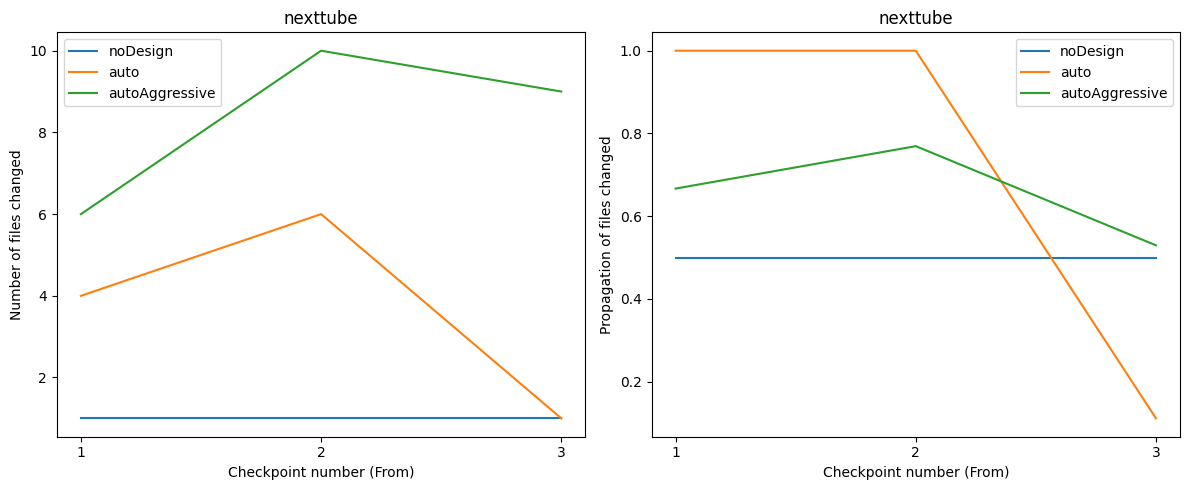

In [19]:
import os 
from metrics.change_coupling.overall_metrics import get_added_files, get_changed_files, get_deleted_files, get_all_modules, get_change_coupling

# data is in the form of [[c1, c2, ...], [c1, c2, ...]]
change_numbers = [] 
change_proportions = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    cur_numbers = [] 
    cur_proportions = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        changed = get_changed_files(prev_impl_dir, impl_dir)
        total = get_all_modules(prev_impl_dir)
        print(f"{prev_impl_dir}->{impl_dir}: {get_changed_files(prev_impl_dir, impl_dir)}")

        cur_numbers.append(len(changed)) 
        cur_proportions.append(len(changed) / len(total))

    change_numbers.append(cur_numbers) 
    change_proportions.append(cur_proportions) 

    # print the change coupling metric 
    impl_dirs = [dirs[mode_no] / x for x in checkpoint_dirs]
    print(impl_dirs)
    print('\n'.join([str(x) for x in (get_change_coupling(impl_dirs))]))

# plot 
from matplotlib import pyplot as plt 
from matplotlib.ticker import MaxNLocator

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, entry in enumerate(change_numbers):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number (From)")
ax1.set_ylabel("Number of files changed")
ax1.set_title(PROBLEM)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend()

for i, entry in enumerate(change_proportions):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number (From)")
ax2.set_ylabel("Propagation of files changed")
ax2.set_title(PROBLEM)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend()

plt.tight_layout()
plt.show()

## Logical lines of code

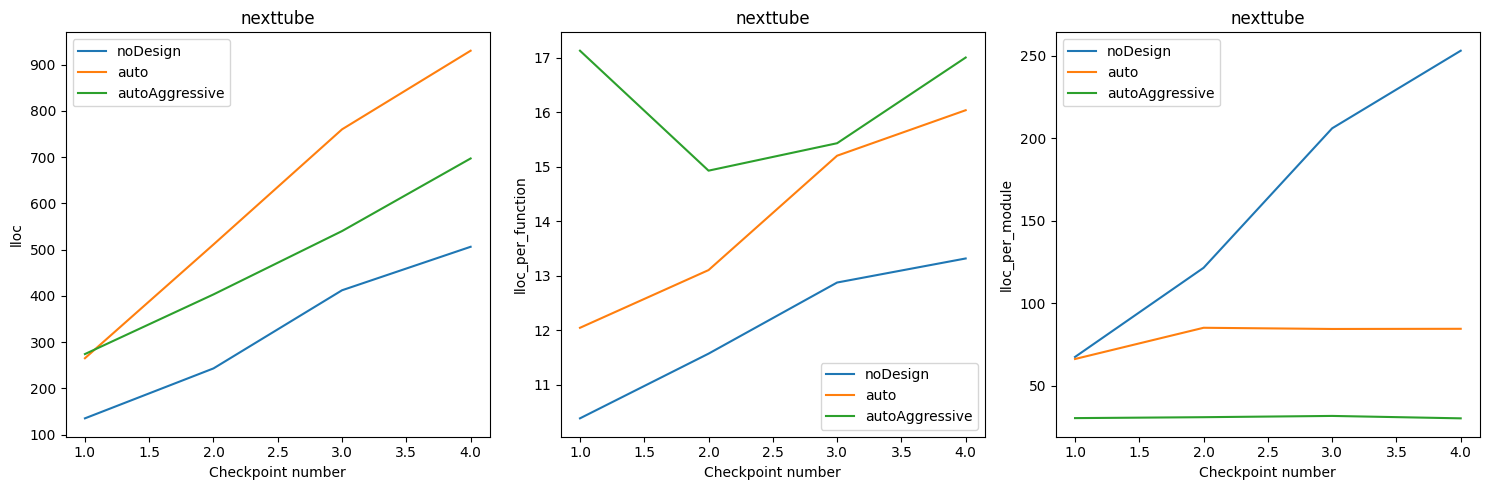

In [20]:
plot(metrics, ["lloc", "lloc_per_function", "lloc_per_module"])

## Functions with high CC / LOC

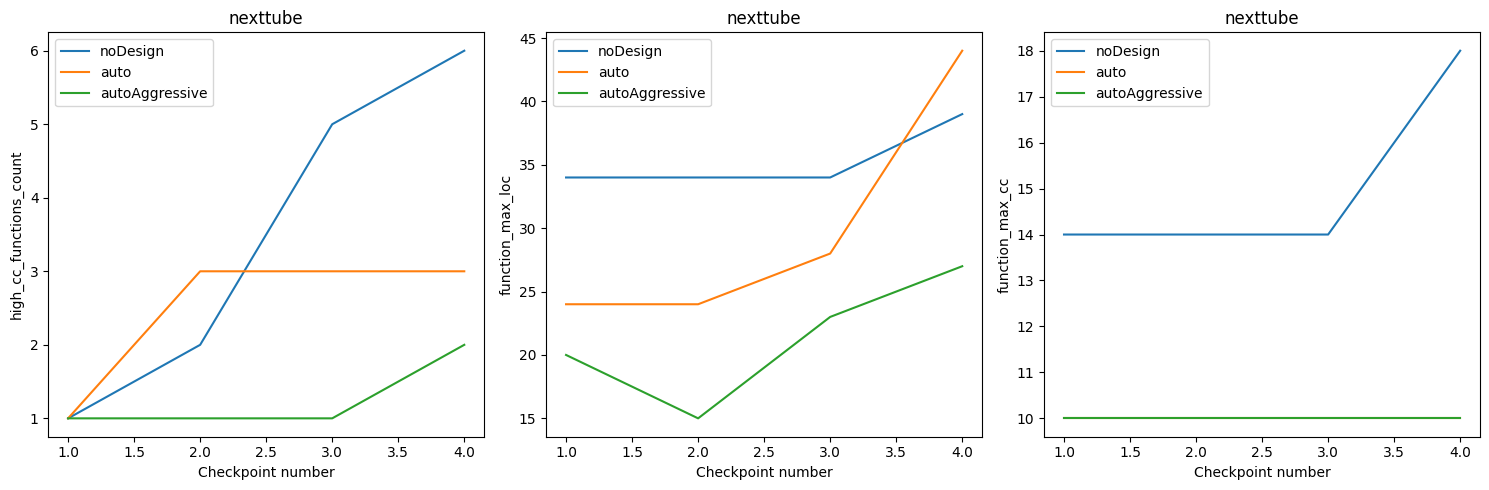

In [21]:
plot(metrics, ["high_cc_functions_count", "function_max_loc", "function_max_cc"])

## Maintainability index (Weighted)

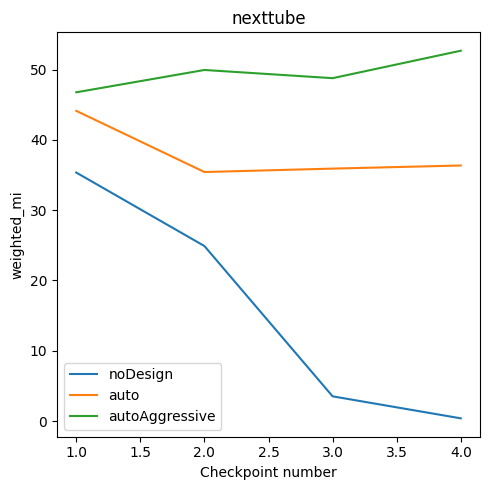

In [22]:
plot(metrics, ["weighted_mi"])

## Duplicated lines and tokens percentage

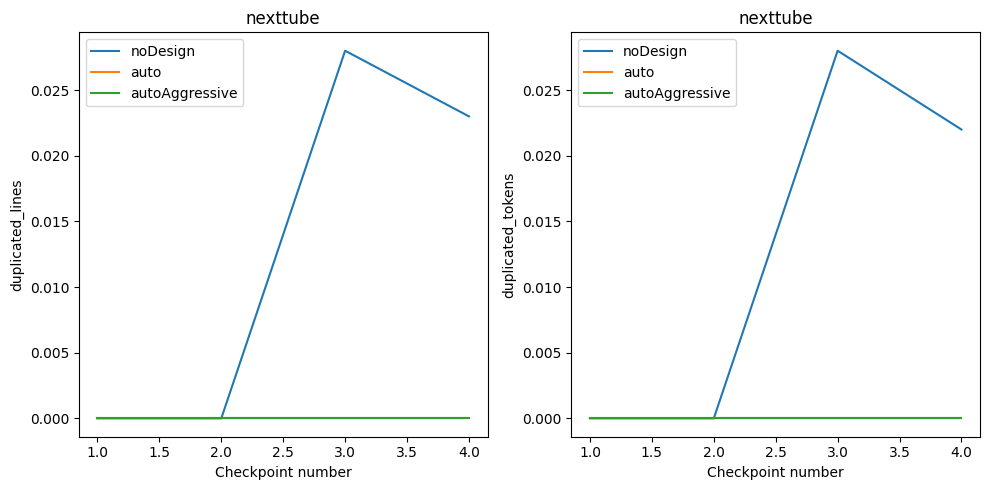

In [23]:
plot(metrics, ["duplicated_lines", "duplicated_tokens"])

## Whether graph has cycles

In [24]:
for i, entry in enumerate(metrics): 
    print(f"{MODES[i]}: {[x["has_cycles"] for x in entry]}")

noDesign: [False, False, False, False]
auto: [False, False, False, False]
autoAggressive: [False, False, False, False]


## NOPM per class

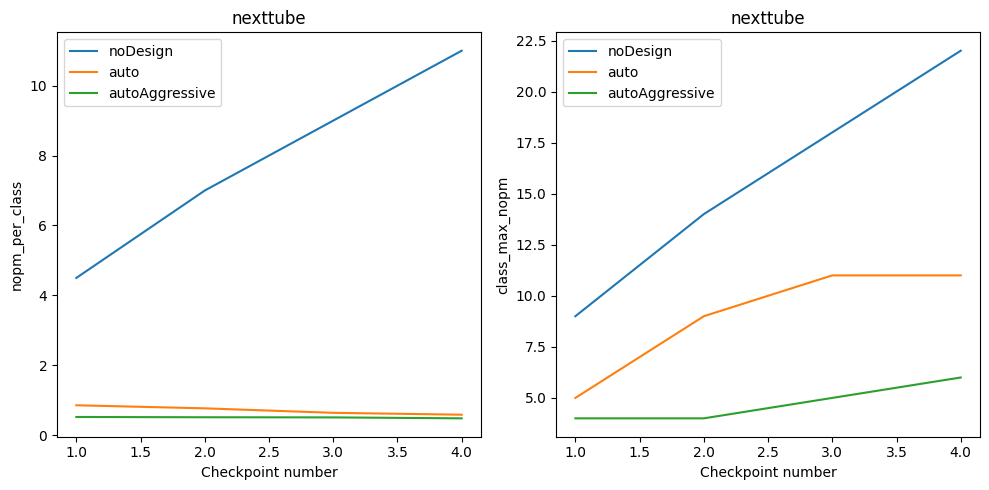

In [25]:
plot(metrics, ["nopm_per_class", "class_max_nopm"])

## Propagation cost, N and impact size

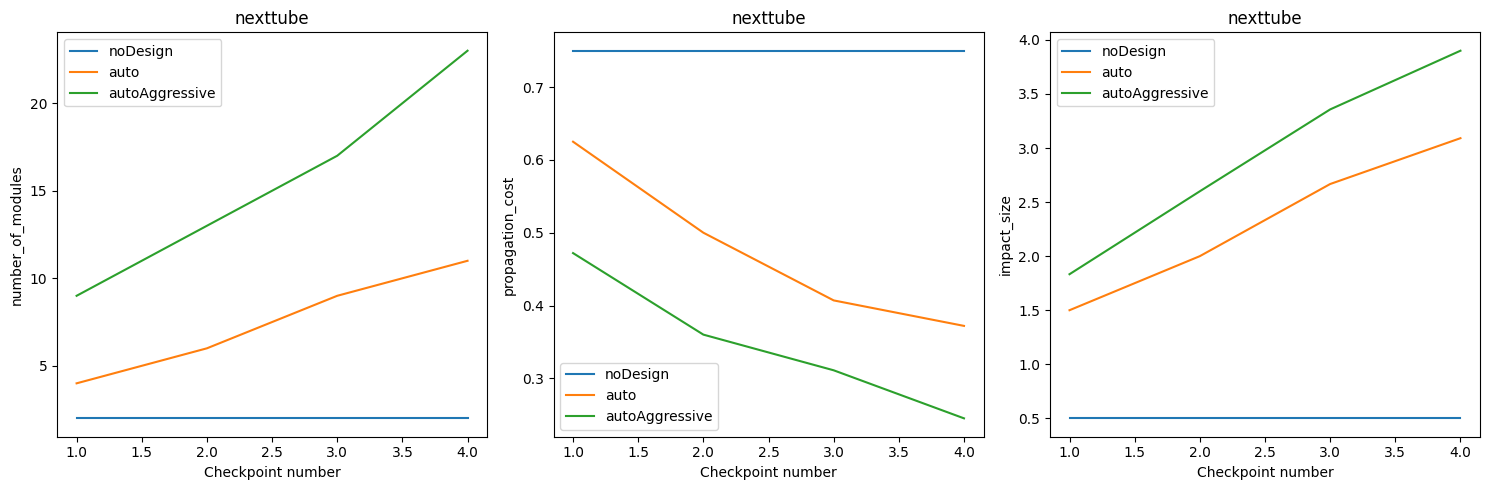

In [26]:
plot(metrics, ["number_of_modules", "propagation_cost", "impact_size"])

## Correctness (scb only)

In [27]:
from modular_main.entry_files import ENTRY_FILES
from scripts.pytest_scb import pytest_scb

# current tests = tests for the current checkpoint, e.g. 8 against 8 
# prev tests = test of previous checkpoints for the current impl, e.g. 8 against 7
current_tests = [] 
prev_tests = [] 
all_tests = [] 

if TYPE == "scb": 
    for mode_no, mode in enumerate(MODES): 
        # Obtain the checkpoint directories names of the problem
        # checkpoint_1, checkpoint_2, ... checkpoint_N
        checkpoint_dirs = []
        for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
            # only extract the top level iteration 
            checkpoint_dirs = dir 
            break 

        # remove directories that does not start with checkpoint_X
        checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
        checkpoint_dirs.sort() 
        N = len(checkpoint_dirs)

        current_tests_mode = [] 
        prev_tests_mode = [] 
        all_tests_mode = [] 

        # walk through each checkpoint 
        for i, checkpoint_name in enumerate(checkpoint_dirs): 
            current_checkpoint = i+1
            impl_dir = dirs[mode_no] / checkpoint_name

            # build the entrypoint path 
            entrypoint_path = Path(f"{impl_dir}/{ENTRY_FILES[PROBLEM]}.py")

            # run tests for checkpoint from N to 1 
            current_tests_ran = 0 
            current_tests_success = 0 
            prev_tests_ran = 0 
            prev_tests_success = 0 

            for cp in range(current_checkpoint, 0, -1): 
                result = pytest_scb(
                    problem_name=PROBLEM, 
                    entrypoint_path=entrypoint_path, 
                    checkpoint_number_to_test_against=cp
                )

                # append to current if it is the latest checkpoint test, else append to prev 
                if cp == N: 
                    current_tests_ran += result["total"]
                    current_tests_success += result["passed"]
                else: 
                    prev_tests_ran += result["total"]
                    prev_tests_success += result["passed"]

            current_tests_mode.append(current_tests_success/current_tests_ran if current_tests_ran>0 else 1)
            prev_tests_mode.append(prev_tests_success/prev_tests_ran if prev_tests_ran>0 else 1)
            all_tests_mode.append((current_tests_success + prev_tests_success)/(current_tests_ran + prev_tests_ran) if (current_tests_ran + prev_tests_ran)>0 else 1)

        current_tests.append(current_tests_mode) 
        prev_tests.append(prev_tests_mode) 
        all_tests.append(all_tests_mode) 

    print(current_tests) 
    print(prev_tests) 
    print(all_tests)    

In [28]:
import matplotlib.pyplot as plt 

if TYPE == "scb": 
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    for mode_no, mode in enumerate(MODES): 
        data = current_tests[mode_no] 
        x = range(1, len(data) + 1) 
        y = data
        ax1.plot(x, y, label=mode)
        ax1.set_xlabel("Checkpoint number")
        ax1.set_ylabel("Current tests pass rate")
        ax1.set_title(PROBLEM)
        ax1.legend()

        data = prev_tests[mode_no] 
        x = range(1, len(data) + 1) 
        y = data
        ax2.plot(x, y, label=mode)
        ax2.set_xlabel("Checkpoint number")
        ax2.set_ylabel("Past tests pass rate")
        ax2.set_title(PROBLEM)
        ax2.legend()

        data = all_tests[mode_no] 
        x = range(1, len(data) + 1) 
        y = data
        ax3.plot(x, y, label=mode)
        ax3.set_xlabel("Checkpoint number")
        ax3.set_ylabel("All tests pass rate")
        ax3.set_title(PROBLEM)
        ax3.legend()

    plt.tight_layout()
    plt.show()

## Spider diagrams (test) 

## 

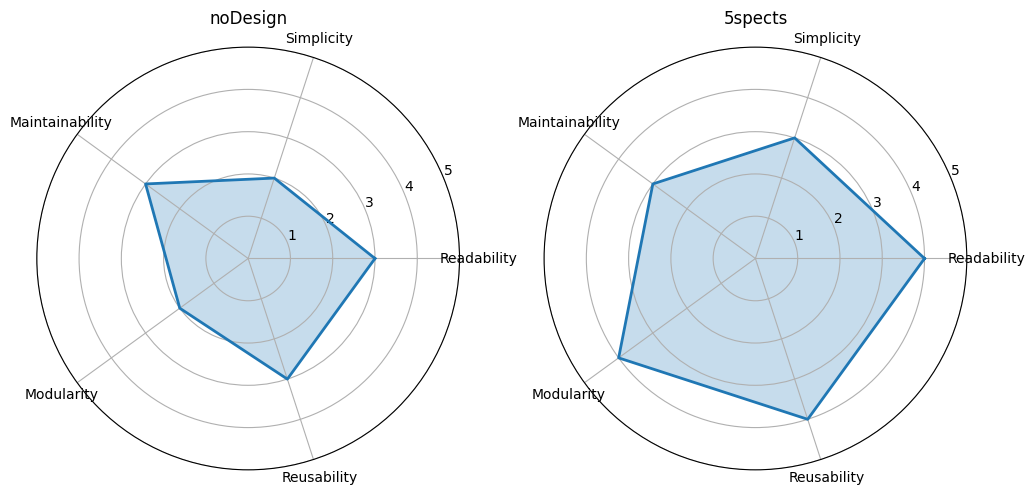

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["Readability", "Simplicity", "Maintainability", "Modularity", "Reusability"]
values_noDesign = [3,2,3,2,3]
values_5aspects = [4,3,3,4,4]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

# Values also need to loop back to the first point
# (Append the first value to the end) 
values_noDesign += values_noDesign[:1]
values_5aspects += values_5aspects[:1]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 6), subplot_kw=dict(polar=True))

# Draw the outline and fill
ax1.plot(angles, values_noDesign, linewidth=2, linestyle='solid')
ax1.fill(angles, values_noDesign, alpha=0.25)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])

ax1.set_title("noDesign")

# Draw the outline and fill
ax2.plot(angles, values_5aspects, linewidth=2, linestyle='solid')
ax2.fill(angles, values_5aspects, alpha=0.25)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax2.set_ylim(0, 5)
ax2.set_yticks([1, 2, 3, 4, 5])

ax2.set_title("5spects")

plt.show()